# Quantum Commerce — Detecção de anomalias e fraudes
### Notebook demonstrativo da arquitetura híbrida: Isolation Forest + Gradient Boosting

**FIAP MBA · AI Foundation and Learning Models · Turma 5AIER**
Trabalho Final — Machine Learning Foundation and Classical Models
**Grupo:** Assis Prestes (RM377711) · Rafael Zaneti (RM377483) · Alecxander Ribeiro de Oliveira (RM378613) · Danilo Sanches (RM378307)

**Repositório:** [github.com/assisprestes/AI-Foundation-and-Learning-Models](https://github.com/assisprestes/AI-Foundation-and-Learning-Models)  
[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/assisprestes/AI-Foundation-and-Learning-Models/blob/master/QuantumCommerce_Deteccao_Fraudes.ipynb)

---

Este notebook acompanha a apresentação e demonstra, de ponta a ponta, a proposta técnica:

| Etapa | O que o notebook mostra |
|---|---|
| 1. Dados | Base sintética de transações da Quantum Commerce (12 países, 4 canais), com fraude rara (< 1%) |
| 2. Divisão temporal | Treino no passado, validação e teste no futuro — sem embaralhar |
| 3. Baseline | Regressão logística |
| 4. Isolation Forest | Score de anomalia **sem usar rótulos** |
| 5. Gradient Boosting | Modelo supervisionado sobre as features |
| 6. Híbrido | Gradient Boosting + score de anomalia como feature + regra de anomalia extrema |
| 7. Avaliação | PR-AUC, recall com falso positivo fixo e recall na **fraude inédita** |
| 8. Decisão | Calibração, limiares por custo e as 4 faixas: aprovar / autenticar / revisar / bloquear |
| 9. Explicabilidade | Importância das features e motivos de uma decisão |
| 10. Operação | Função de scoring (simulando a API do checkout) e monitoramento de drift (PSI) |

> **Por que dados sintéticos?** Os dados reais da Quantum Commerce não estão disponíveis. A base é gerada com padrões
> realistas de fraude (teste de cartões, tomada de conta) e, no último mês, surge um **golpe novo** (abuso de devolução)
> que nunca apareceu no treino — exatamente o cenário que justifica a arquitetura híbrida. Para usar dados públicos,
> basta trocar a etapa 1 por um dataset do Kaggle (ex.: *IEEE-CIS Fraud Detection*).

## 0. Configuração
Bibliotecas: `numpy`, `pandas`, `matplotlib`, `scikit-learn`. Se `xgboost` e `shap` estiverem instalados
(`pip install xgboost shap`), o notebook os usa automaticamente; caso contrário, usa o
`HistGradientBoostingClassifier` do scikit-learn — a mesma família de algoritmo (gradient boosting em histogramas, como o LightGBM).

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(42)

try:
    from xgboost import XGBClassifier
    USA_XGB = True
except ImportError:
    USA_XGB = False

try:
    import shap
    USA_SHAP = True
except ImportError:
    USA_SHAP = False

print(f"XGBoost disponível: {USA_XGB}  |  SHAP disponível: {USA_SHAP}")

# Paleta (validada para daltonismo) e estilo dos gráficos
COR = {"Regressão logística": "#2D6CDF", "Isolation Forest": "#1E9A8A",
       "Gradient Boosting": "#D9822B", "Híbrido": "#C42F35"}
COR_LEGIT, COR_FRAUDE = "#2D6CDF", "#C42F35"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#FCFCFB", "axes.facecolor": "#FCFCFB",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8BEC8",
    "axes.grid": True, "grid.color": "#E6E8EC", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
    "axes.labelcolor": "#3E4A5C", "xtick.color": "#5E6878", "ytick.color": "#5E6878",
})

XGBoost disponível: False  |  SHAP disponível: False


## 1. Geração da base de transações

Cada linha é um pedido. As features espelham a tabela de dados da apresentação:

- **Transação:** `valor`, `hora`, `parcelas`, `canal`, `meio_pagamento`, `pais`
- **Cliente e conta:** `idade_conta_dias`, `n_compras_hist`, `troca_email_recente`
- **Dispositivo e sessão:** `dist_ip_entrega_km`
- **Velocidade:** `cartoes_por_dispositivo_1h`, `tentativas_falhas_10min`
- **Devoluções:** `taxa_devolucao_cliente`

Três tipos de fraude:

| Tipo | Padrão | Quando aparece |
|---|---|---|
| Teste de cartões | muitos cartões por dispositivo, tentativas falhas, conta nova, madrugada | todo o período |
| Tomada de conta (ATO) | troca recente de e-mail, IP longe do endereço, valor alto | todo o período |
| **Abuso de devolução (novo)** | taxa de devolução muito alta, valor alto | **só no último mês** |

In [2]:
PAISES = ["BR", "MX", "AR", "CL", "CO", "PE", "US", "CA", "PT", "ES", "UK", "DE"]
PESO_PAIS = np.array([25, 14, 8, 6, 7, 4, 12, 4, 4, 6, 5, 5], dtype=float); PESO_PAIS /= PESO_PAIS.sum()
CANAIS = ["site", "app", "marketplace", "loja"]
MEIOS = ["cartao_credito", "cartao_debito", "carteira_digital", "boleto"]
N_DIAS = 180


def gerar_legitimas(n):
    idade = RNG.exponential(600, n).clip(1, 4000)
    return pd.DataFrame({
        "valor": RNG.lognormal(4.5, 0.8, n),
        "hora": (RNG.normal(15, 4, n) % 24).astype(int),
        "parcelas": RNG.choice([1, 2, 3, 6, 10, 12], n, p=[.55, .1, .12, .1, .08, .05]),
        "canal": RNG.choice(CANAIS, n, p=[.4, .4, .15, .05]),
        "meio_pagamento": RNG.choice(MEIOS, n, p=[.55, .15, .2, .1]),
        "pais": RNG.choice(PAISES, n, p=PESO_PAIS),
        "idade_conta_dias": idade,
        "n_compras_hist": RNG.poisson(1 + idade / 60),
        "troca_email_recente": RNG.binomial(1, 0.02, n),
        "dist_ip_entrega_km": RNG.lognormal(2.5, 1.0, n),
        "cartoes_por_dispositivo_1h": 1 + RNG.poisson(0.08, n),
        "tentativas_falhas_10min": RNG.poisson(0.1, n),
        "taxa_devolucao_cliente": RNG.beta(2, 20, n),
        "tipo_fraude": "legitima",
    })


def gerar_teste_cartoes(n):
    df = gerar_legitimas(n)
    df["cartoes_por_dispositivo_1h"] = RNG.integers(2, 9, n)
    df["tentativas_falhas_10min"] = RNG.poisson(4, n) + 1
    df["idade_conta_dias"] = RNG.exponential(10, n).clip(0, 60)
    df["n_compras_hist"] = RNG.poisson(0.5, n)
    df["hora"] = RNG.choice([0, 1, 2, 3, 4, 5, 23], n)
    df["valor"] = RNG.lognormal(3.8, 1.0, n)
    df["tipo_fraude"] = "teste_cartoes"
    return df


def gerar_tomada_conta(n):
    df = gerar_legitimas(n)
    df["troca_email_recente"] = RNG.binomial(1, 0.7, n)
    df["dist_ip_entrega_km"] = RNG.lognormal(6.0, 1.0, n)
    df["valor"] = RNG.lognormal(6.0, 0.7, n)
    df["parcelas"] = RNG.choice([1, 10, 12], n, p=[.3, .3, .4])
    df["tipo_fraude"] = "tomada_conta"
    return df


def gerar_abuso_devolucao(n):
    df = gerar_legitimas(n)
    df["taxa_devolucao_cliente"] = RNG.beta(12, 4, n)
    df["valor"] = RNG.lognormal(6.3, 0.4, n)
    df["n_compras_hist"] = RNG.poisson(70, n)
    df["dist_ip_entrega_km"] = RNG.lognormal(4.5, 0.6, n)
    df["tipo_fraude"] = "abuso_devolucao"
    return df


def com_datas(df, dia_ini, dia_fim):
    df["dia"] = RNG.integers(dia_ini, dia_fim, len(df))
    return df


N_LEGIT = 150_000
partes = [
    com_datas(gerar_legitimas(N_LEGIT), 0, N_DIAS),
    com_datas(gerar_teste_cartoes(520), 0, N_DIAS),
    com_datas(gerar_tomada_conta(520), 0, N_DIAS),
    com_datas(gerar_abuso_devolucao(160), 150, N_DIAS),  # golpe novo: só no último mês
]
df = pd.concat(partes, ignore_index=True).sample(frac=1, random_state=42).sort_values("dia").reset_index(drop=True)

# Ruído realista: parte dos rótulos de fraude nunca é confirmada (rótulos incompletos)
df["fraude"] = (df["tipo_fraude"] != "legitima").astype(int)
nao_confirmadas = (df["fraude"] == 1) & (RNG.random(len(df)) < 0.10)
df.loc[nao_confirmadas, "fraude"] = 0

print(f"Transações: {len(df):,}  |  Fraudes rotuladas: {df.fraude.sum():,}  ({df.fraude.mean():.2%})")
display(df.groupby("tipo_fraude").size().rename("transações").to_frame())

Transações: 151,200  |  Fraudes rotuladas: 1,084  (0.72%)


,transações
tipo_fraude,
abuso_devolucao,160
legitima,150000
teste_cartoes,520
tomada_conta,520


### Desbalanceamento: por que acurácia não serve
Com menos de 1% de fraude, um modelo que aprova **tudo** já tem mais de 99% de acurácia — e não pega nenhuma fraude.

Acurácia de um modelo que aprova tudo: 99.28%  →  fraudes detectadas: 0


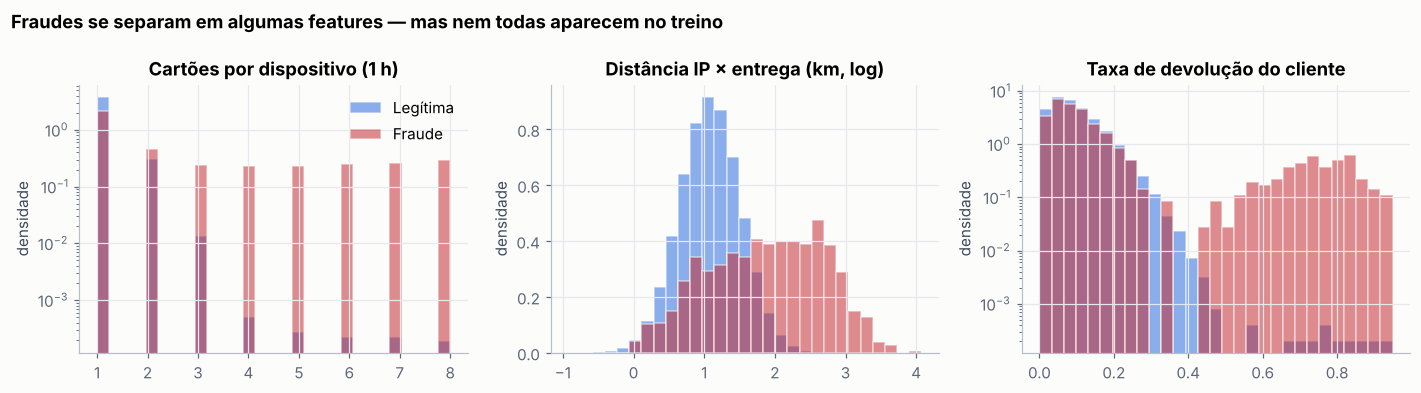

In [3]:
acc_trivial = 1 - df.fraude.mean()
print(f"Acurácia de um modelo que aprova tudo: {acc_trivial:.2%}  →  fraudes detectadas: 0")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, titulo, log in [
    (axes[0], "cartoes_por_dispositivo_1h", "Cartões por dispositivo (1 h)", True),
    (axes[1], "dist_ip_entrega_km", "Distância IP × entrega (km, log)", False),
    (axes[2], "taxa_devolucao_cliente", "Taxa de devolução do cliente", True),
]:
    x = np.log10(df[col]) if col == "dist_ip_entrega_km" else df[col]
    bins = np.linspace(x.min(), x.max(), 30)
    ax.hist(x[df.fraude == 0], bins=bins, color=COR_LEGIT, alpha=.55, density=True, label="Legítima", edgecolor="#FCFCFB", linewidth=1)
    ax.hist(x[df.fraude == 1], bins=bins, color=COR_FRAUDE, alpha=.55, density=True, label="Fraude", edgecolor="#FCFCFB", linewidth=1)
    ax.set_title(titulo); ax.set_ylabel("densidade")
    if log: ax.set_yscale("log")
axes[0].legend(frameon=False)
fig.suptitle("Fraudes se separam em algumas features — mas nem todas aparecem no treino", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 2. Divisão temporal
Em fraude, embaralhar os dados vaza informação do futuro e infla as métricas. Por isso:

- **Treino:** dias 0–119 (4 meses)
- **Validação:** dias 120–149 (calibração e escolha de limiares)
- **Teste:** dias 150–179 (último mês — onde surge o golpe novo)

In [4]:
CAT = ["canal", "meio_pagamento", "pais"]
NUM = ["valor", "hora", "parcelas", "idade_conta_dias", "n_compras_hist", "troca_email_recente",
       "dist_ip_entrega_km", "cartoes_por_dispositivo_1h", "tentativas_falhas_10min", "taxa_devolucao_cliente"]
FEATURES = NUM + CAT

df["valor_log"] = np.log1p(df["valor"])
df["dist_log"] = np.log1p(df["dist_ip_entrega_km"])

treino = df[df.dia < 120].copy()
valid = df[(df.dia >= 120) & (df.dia < 150)].copy()
teste = df[df.dia >= 150].copy()

resumo = pd.DataFrame({
    "período (dias)": ["0–119", "120–149", "150–179"],
    "transações": [len(treino), len(valid), len(teste)],
    "fraudes": [treino.fraude.sum(), valid.fraude.sum(), teste.fraude.sum()],
    "taxa de fraude": [f"{d.fraude.mean():.2%}" for d in (treino, valid, teste)],
    "fraudes do golpe novo": [(d.tipo_fraude == "abuso_devolucao").sum() for d in (treino, valid, teste)],
}, index=["Treino", "Validação", "Teste"])
display(resumo)

,período (dias),transações,fraudes,taxa de fraude,fraudes do golpe novo
Treino,0–119,101041,626,0.62%,0
Validação,120–149,24954,151,0.61%,0
Teste,150–179,25205,307,1.22%,160


## 3. Baseline — Regressão logística
Modelo linear simples, com `class_weight="balanced"` para lidar com o desbalanceamento. Serve de régua.

In [5]:
pre_linear = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])
modelo_lr = Pipeline([("pre", pre_linear), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
modelo_lr.fit(treino[FEATURES], treino.fraude)
p_lr = modelo_lr.predict_proba(teste[FEATURES])[:, 1]
print(f"PR-AUC (teste) — Regressão logística: {average_precision_score(teste.fraude, p_lr):.3f}")

PR-AUC (teste) — Regressão logística: 0.532


## 4. Isolation Forest — detecção de anomalias sem rótulo

O Isolation Forest constrói árvores com cortes aleatórios. Pontos **raros e diferentes** são isolados com
**poucos cortes** → caminho curto na árvore → score de anomalia alto.

Treinamos **apenas com transações legítimas** do período de treino: o modelo aprende o que é "normal"
e marca qualquer desvio — inclusive padrões de fraude que nunca foram rotulados.

PR-AUC (teste) — Isolation Forest sozinho: 0.816
Limiar de anomalia extrema (p99,5 das legítimas): 0.601


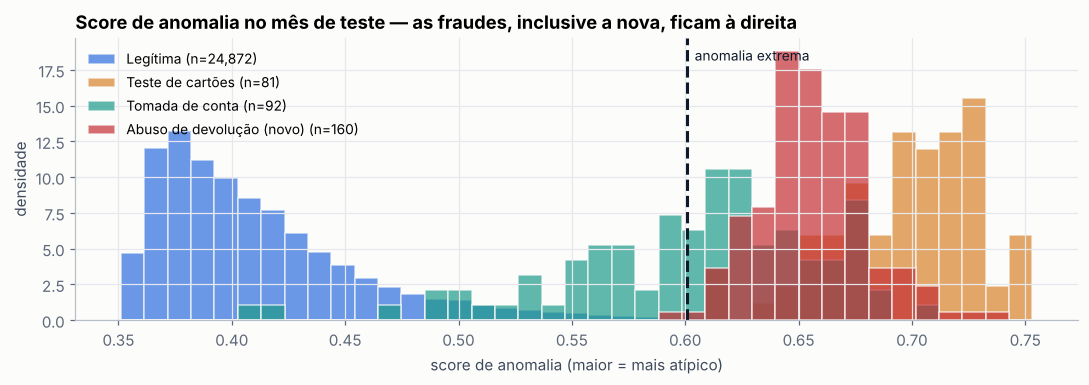

In [6]:
NUM_IF = ["valor_log", "hora", "parcelas", "idade_conta_dias", "n_compras_hist", "troca_email_recente",
          "dist_log", "cartoes_por_dispositivo_1h", "tentativas_falhas_10min", "taxa_devolucao_cliente"]

escala_if = StandardScaler().fit(treino.loc[treino.fraude == 0, NUM_IF])
modelo_if = IsolationForest(n_estimators=300, max_samples=4096, contamination="auto", random_state=42, n_jobs=-1)
modelo_if.fit(escala_if.transform(treino.loc[treino.fraude == 0, NUM_IF]))


def score_anomalia(d):
    """Quanto maior, mais anômalo (invertemos o score_samples do sklearn)."""
    return -modelo_if.score_samples(escala_if.transform(d[NUM_IF]))


for d in (treino, valid, teste):
    d["anomaly_score"] = score_anomalia(d)

# Percentil 99,5% das legítimas do treino: acima disso, a transação é "anomalia extrema"
REF_ANOMALIA = np.sort(treino.loc[treino.fraude == 0, "anomaly_score"].to_numpy())
LIMIAR_ANOMALIA = np.quantile(REF_ANOMALIA, 0.995)


def cauda_anomalia(s):
    """0 abaixo do p99,5 das legítimas; cresce até 1 no extremo da cauda."""
    pct = np.searchsorted(REF_ANOMALIA, s) / len(REF_ANOMALIA)
    return np.clip((pct - 0.995) / 0.005, 0, 1)
print(f"PR-AUC (teste) — Isolation Forest sozinho: {average_precision_score(teste.fraude, teste.anomaly_score):.3f}")
print(f"Limiar de anomalia extrema (p99,5 das legítimas): {LIMIAR_ANOMALIA:.3f}")

fig, ax = plt.subplots(figsize=(10, 3.6))
bins = np.linspace(teste.anomaly_score.min(), teste.anomaly_score.max(), 40)
for tipo, cor, rot in [("legitima", COR_LEGIT, "Legítima"), ("teste_cartoes", "#D9822B", "Teste de cartões"),
                       ("tomada_conta", "#1E9A8A", "Tomada de conta"), ("abuso_devolucao", COR_FRAUDE, "Abuso de devolução (novo)")]:
    s = teste.loc[teste.tipo_fraude == tipo, "anomaly_score"]
    ax.hist(s, bins=bins, density=True, alpha=.7, color=cor, label=f"{rot} (n={len(s):,})", edgecolor="#FCFCFB", linewidth=1)
ax.axvline(LIMIAR_ANOMALIA, color="#0E1A2B", lw=2, ls="--")
ax.text(LIMIAR_ANOMALIA, ax.get_ylim()[1] * .92, "  anomalia extrema", color="#0E1A2B", fontsize=9)
ax.set_title("Score de anomalia no mês de teste — as fraudes, inclusive a nova, ficam à direita", loc="left")
ax.set_xlabel("score de anomalia (maior = mais atípico)"); ax.set_ylabel("densidade")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Gradient Boosting supervisionado
Aprende os padrões de fraude **já rotulados**. O desbalanceamento é tratado com peso de classe
(`scale_pos_weight` no XGBoost / `class_weight` no scikit-learn), sem oversampling artificial.

In [7]:
peso_pos = (treino.fraude == 0).sum() / treino.fraude.sum()


def novo_gb():
    if USA_XGB:
        return XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=peso_pos, eval_metric="aucpr",
                             random_state=42, n_jobs=-1)
    return HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=5,
                                          class_weight={0: 1, 1: peso_pos}, random_state=42)


def matriz(d, com_anomalia=False):
    X = d[NUM].copy()
    for c in CAT:
        X[c] = d[c].astype("category").cat.set_categories(sorted(df[c].unique())).cat.codes
    if com_anomalia:
        X["anomaly_score"] = d["anomaly_score"]
    return X


modelo_gb = novo_gb().fit(matriz(treino), treino.fraude)
p_gb = modelo_gb.predict_proba(matriz(teste))[:, 1]
nome_gb = "XGBoost" if USA_XGB else "HistGradientBoosting (scikit-learn)"
print(f"PR-AUC (teste) — {nome_gb} sozinho: {average_precision_score(teste.fraude, p_gb):.3f}")

PR-AUC (teste) — HistGradientBoosting (scikit-learn) sozinho: 0.742


## 6. Modelo híbrido — Gradient Boosting + Isolation Forest

Duas formas de combinação, como na apresentação:

1. **Stacking:** o `anomaly_score` entra como feature do Gradient Boosting.
2. **Regra de anomalia extrema:** se o score de anomalia passar do percentil 99,5% das legítimas, a transação
   vai **no mínimo para revisão**, mesmo que o modelo supervisionado não reconheça o padrão.

O score de ranking do híbrido é `max(probabilidade do GB, cauda de anomalia)`: a anomalia só entra
no score quando está na cauda extrema (acima do p99,5 das legítimas), para não inflar alarmes falsos.

In [8]:
modelo_hib = novo_gb().fit(matriz(treino, True), treino.fraude)


def prob_hibrido(d):
    return modelo_hib.predict_proba(matriz(d, True))[:, 1]


p_hib_bruto = prob_hibrido(teste)
print(f"PR-AUC (teste) — GB + anomaly_score (só stacking): {average_precision_score(teste.fraude, p_hib_bruto):.3f}")

PR-AUC (teste) — GB + anomaly_score (só stacking): 0.800


## 7. Calibração e limiares por custo

**Calibração isotônica** (ajustada na validação) transforma o score em uma probabilidade confiável.

Os **limiares não são 0,5**: são escolhidos pelo **custo esperado** de cada decisão.
Premissas ilustrativas (ajustar com a área de risco):

| Erro | Custo assumido |
|---|---|
| Fraude aprovada (falso negativo) | valor da transação |
| Cliente bom bloqueado (falso positivo) | R$ 40 (margem perdida + atrito/churn) |
| Revisão manual | R$ 6 por caso |
| Autenticação extra (3-D Secure) | R$ 1,50 por caso + 5% de abandono |

In [9]:
p_val = prob_hibrido(valid)
calibrador = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_val, valid.fraude)


def score_final(d):
    """Retorna a probabilidade calibrada e o indicador de anomalia extrema (1 = acima do p99,5)."""
    p = calibrador.predict(prob_hibrido(d))
    piso = (d["anomaly_score"].to_numpy() >= LIMIAR_ANOMALIA).astype(float)
    return p, piso


CUSTO_FP_BLOQUEIO, CUSTO_REVISAO, CUSTO_AUTENT, ABANDONO_AUTENT = 40.0, 6.0, 1.5, 0.05


def custo_total(d, p, piso, t_aut, t_rev, t_blq):
    y, v = d.fraude.to_numpy(), d.valor.to_numpy()
    acao = np.select([p >= t_blq, (p >= t_rev) | (piso == 1), p >= t_aut], ["bloquear", "revisar", "autenticar"], "aprovar")
    custo = np.zeros(len(d))
    custo += np.where((acao == "aprovar") & (y == 1), v, 0)                       # fraude passou
    custo += np.where((acao == "autenticar") & (y == 1), 0.3 * v, 0)              # 3DS barra ~70% das fraudes
    custo += np.where(acao == "autenticar", CUSTO_AUTENT, 0)
    custo += np.where((acao == "autenticar") & (y == 0), ABANDONO_AUTENT * 0.1 * v, 0)  # margem perdida no abandono
    custo += np.where(acao == "revisar", CUSTO_REVISAO, 0)
    custo += np.where((acao == "bloquear") & (y == 0), CUSTO_FP_BLOQUEIO, 0)
    return custo.sum(), acao


p_v, piso_v = score_final(valid)
grade = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
melhor = min(((custo_total(valid, p_v, piso_v, a, r, b)[0], a, r, b)
              for a in grade for r in grade for b in grade if a < r < b), key=lambda x: x[0])
_, T_AUT, T_REV, T_BLQ = melhor
print(f"Limiares ótimos na validação → autenticar ≥ {T_AUT}  |  revisar ≥ {T_REV}  |  bloquear ≥ {T_BLQ}")

Limiares ótimos na validação → autenticar ≥ 0.01  |  revisar ≥ 0.02  |  bloquear ≥ 0.7


## 8. Avaliação no mês de teste
Métricas recomendadas para fraude:
- **PR-AUC** — área sob a curva precisão × recall (robusta ao desbalanceamento)
- **Recall @ 1% FPR** — quanta fraude é pega aceitando no máximo 1% de alarmes falsos sobre clientes bons
- **Recall na fraude nova** — o golpe de abuso de devolução, ausente do treino

In [10]:
p_t, piso_t = score_final(teste)
s_hibrido = np.maximum(prob_hibrido(teste), cauda_anomalia(teste.anomaly_score.to_numpy()))

scores = {
    "Regressão logística": p_lr,
    "Isolation Forest": teste.anomaly_score.to_numpy(),
    "Gradient Boosting": p_gb,
    "Híbrido": s_hibrido,
}
y_t = teste.fraude.to_numpy()
novo = (teste.tipo_fraude == "abuso_devolucao").to_numpy()
conhecida = teste.tipo_fraude.isin(["teste_cartoes", "tomada_conta"]).to_numpy()


def recall_em_fpr(y, s, fpr_max=0.01, mascara=None):
    t = np.quantile(s[y == 0], 1 - fpr_max)
    m = (y == 1) if mascara is None else mascara
    return (s[m] > t).mean()


linhas = []
for nome, s in scores.items():
    linhas.append({
        "Modelo": nome,
        "PR-AUC": average_precision_score(y_t, s),
        "Recall @1% FPR (todas)": recall_em_fpr(y_t, s),
        "Recall @1% FPR (fraude conhecida)": recall_em_fpr(y_t, s, mascara=conhecida),
        "Recall @1% FPR (fraude NOVA)": recall_em_fpr(y_t, s, mascara=novo),
    })
resultado = pd.DataFrame(linhas).set_index("Modelo")
display(resultado.style.format("{:.3f}").background_gradient(cmap="Reds", axis=0))

,PR-AUC,Recall @1% FPR (todas),Recall @1% FPR (fraude conhecida),Recall @1% FPR (fraude NOVA)
Modelo,,,,
Regressão logística,0.532,0.564,0.971,0.138
Isolation Forest,0.816,0.938,0.873,1.000
Gradient Boosting,0.742,0.834,0.988,0.662
Híbrido,0.858,0.987,0.983,0.988


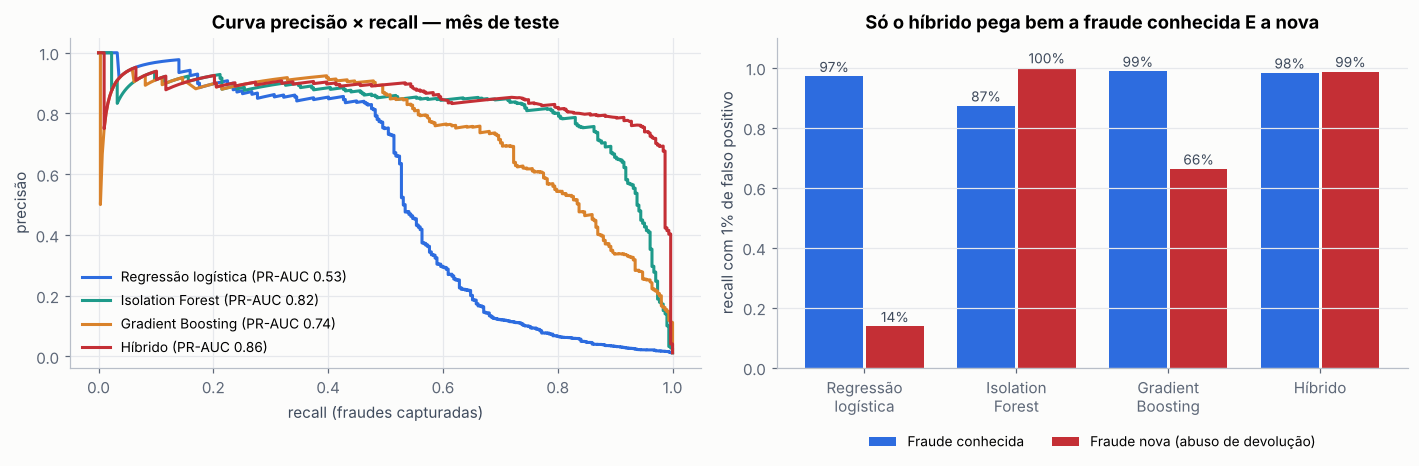

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for nome, s in scores.items():
    prec, rec, _ = precision_recall_curve(y_t, s)
    axes[0].plot(rec, prec, lw=2, color=COR[nome], label=f"{nome} (PR-AUC {average_precision_score(y_t, s):.2f})")
axes[0].set_xlabel("recall (fraudes capturadas)"); axes[0].set_ylabel("precisão")
axes[0].set_title("Curva precisão × recall — mês de teste"); axes[0].legend(frameon=False, fontsize=9, loc="lower left")

nomes = list(scores)
x = np.arange(len(nomes)); w = 0.38
v_con = resultado["Recall @1% FPR (fraude conhecida)"].to_numpy()
v_nov = resultado["Recall @1% FPR (fraude NOVA)"].to_numpy()
b1 = axes[1].bar(x - w / 2 - 0.01, v_con, w, color="#2D6CDF", label="Fraude conhecida")
b2 = axes[1].bar(x + w / 2 + 0.01, v_nov, w, color="#C42F35", label="Fraude nova (abuso de devolução)")
for barras in (b1, b2):
    for b in barras:
        axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015, f"{b.get_height():.0%}",
                     ha="center", fontsize=9, color="#3E4A5C")
axes[1].set_xticks(x, [n.replace(" ", "\n", 1) for n in nomes]); axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("recall com 1% de falso positivo"); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Só o híbrido pega bem a fraude conhecida E a nova")
axes[1].legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
plt.tight_layout(); plt.show()

**Leitura:** o Gradient Boosting é o melhor em fraude conhecida, mas deixa passar uma parte relevante do golpe novo —
ele nunca viu esse padrão rotulado e só o pega quando ele "se parece" com fraudes antigas. O Isolation Forest enxerga
o golpe novo, mas perde fraude conhecida e, sozinho, gera mais alarmes falsos. O **híbrido** mantém a força do
supervisionado e herda a cobertura do não supervisionado — melhor PR-AUC e melhor recall nos dois tipos.

## 9. Decisão operacional — as quatro faixas
Aplicando os limiares escolhidos por custo ao mês de teste:

In [12]:
custo_hib, acao_t = custo_total(teste, p_t, piso_t, T_AUT, T_REV, T_BLQ)
custo_aprova_tudo = teste.loc[teste.fraude == 1, "valor"].sum()
teste["acao"] = acao_t

ordem = ["aprovar", "autenticar", "revisar", "bloquear"]
tab = (teste.groupby("acao").agg(transacoes=("fraude", "size"), fraudes=("fraude", "sum"))
       .reindex(ordem).fillna(0).astype(int))
tab["% das transações"] = (tab.transacoes / len(teste)).map("{:.2%}".format)
tab["% das fraudes"] = (tab.fraudes / teste.fraude.sum()).map("{:.1%}".format)
display(tab)

print(f"Custo estimado sem modelo (aprovar tudo): R$ {custo_aprova_tudo:,.0f}")
print(f"Custo estimado com o modelo híbrido:     R$ {custo_hib:,.0f}")
print(f"Redução estimada no mês de teste:        {1 - custo_hib / custo_aprova_tudo:.0%}  (premissas ilustrativas)")

,transacoes,fraudes,% das transações,% das fraudes
acao,,,,
aprovar,24709,4,98.03%,1.3%
autenticar,0,0,0.00%,0.0%
revisar,326,151,1.29%,49.2%
bloquear,170,152,0.67%,49.5%


Custo estimado sem modelo (aprovar tudo): R$ 132,278
Custo estimado com o modelo híbrido:     R$ 3,853
Redução estimada no mês de teste:        97%  (premissas ilustrativas)


> **Atenção ao ler estes números:** na base sintética as fraudes se separam bem das legítimas, então o resultado é
> otimista e a faixa de autenticação fica quase vazia. Em dados reais há muito mais casos ambíguos — é justamente
> neles que a autenticação extra reduz o atrito em vez de bloquear. O que vale aqui é o **método**, não o percentual.

## 10. Explicabilidade
**Global:** quais features mais pesam no modelo híbrido (importância por permutação, medida em PR-AUC).
**Local:** os principais motivos de uma decisão específica — o que o analista vê na mesa de revisão.

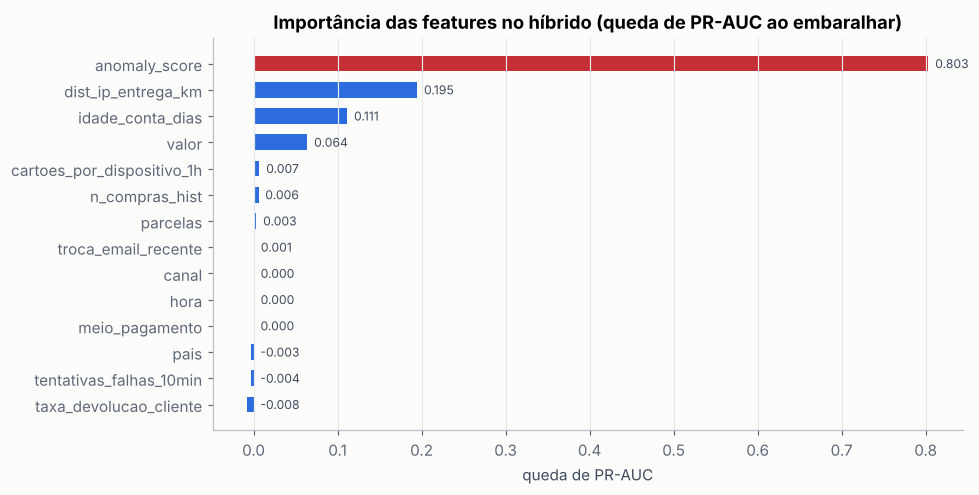

In [13]:
amostra = valid  # importância medida na validação (período sem o golpe novo)
imp = permutation_importance(modelo_hib, matriz(amostra, True), amostra.fraude, scoring="average_precision",
                             n_repeats=3, random_state=42, n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=matriz(amostra, True).columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.6))
cores = ["#C42F35" if c == "anomaly_score" else "#2D6CDF" for c in imp_s.index]
ax.barh(imp_s.index, imp_s.values, color=cores, height=0.6)
for i, v in enumerate(imp_s.values):
    ax.text(max(v, 0) + imp_s.max() * 0.01, i, f"{v:.3f}", va="center", fontsize=8, color="#3E4A5C")
ax.set_title("Importância das features no híbrido (queda de PR-AUC ao embaralhar)")
ax.set_xlabel("queda de PR-AUC"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [14]:
def motivos(linha, n=5):
    """Explicação local: compara cada feature com a mediana das legítimas e mede o efeito no score
    ao trocar o valor da transação pela mediana (aproximação simples; com SHAP instalado, use shap.TreeExplainer)."""
    base = matriz(linha, True)
    p0 = modelo_hib.predict_proba(base)[:, 1][0]
    ref = matriz(treino[treino.fraude == 0], True).median()
    efeitos = {}
    for c in base.columns:
        x = base.copy(); x[c] = ref[c]
        efeitos[c] = p0 - modelo_hib.predict_proba(x)[:, 1][0]
    ef = pd.Series(efeitos).sort_values(ascending=False).head(n)
    return p0, pd.DataFrame({"valor na transação": base.iloc[0][ef.index].round(2),
                             "mediana legítimas": ref[ef.index].round(2),
                             "contribuição ao risco": ef.round(3)})


caso = teste[(teste.acao == "bloquear") & (teste.tipo_fraude == "tomada_conta")].head(1)
if caso.empty:
    caso = teste[teste.acao == "bloquear"].head(1)
p0, tab_motivos = motivos(caso)
print(f"Transação {caso.index[0]} | país {caso.pais.iloc[0]} | valor R$ {caso.valor.iloc[0]:,.2f} | "
      f"ação: {caso.acao.iloc[0].upper()} | anomalia extrema: {bool(caso.anomaly_score.iloc[0] >= LIMIAR_ANOMALIA)}")
display(tab_motivos)

if USA_SHAP and USA_XGB:
    explainer = shap.TreeExplainer(modelo_hib)
    sv = explainer.shap_values(matriz(caso, True))
    display(pd.Series(sv[0], index=matriz(caso, True).columns).sort_values(key=abs, ascending=False).head(5).rename("SHAP"))

Transação 126106 | país MX | valor R$ 255.36 | ação: BLOQUEAR | anomalia extrema: True


,valor na transação,mediana legítimas,contribuição ao risco
anomaly_score,0.64,0.40,0.636
dist_ip_entrega_km,477.32,12.16,0.248
valor,255.36,90.43,0.001
parcelas,10.00,1.00,0.000
taxa_devolucao_cliente,0.17,0.08,0.000


## 11. Scoring em tempo real — simulação da API do checkout
Uma função recebe o pedido, calcula as features, aplica Isolation Forest → Gradient Boosting → calibração → regra
de anomalia e devolve **score, ação e latência**. Meta: < 100 ms.

In [15]:
modelo_if.set_params(n_jobs=1)  # em chamada unitária, paralelismo só adiciona overhead


def score_transacao(pedido: dict) -> dict:
    inicio = time.perf_counter()
    d = pd.DataFrame([pedido])
    d["valor_log"] = np.log1p(d["valor"]); d["dist_log"] = np.log1p(d["dist_ip_entrega_km"])
    d["anomaly_score"] = score_anomalia(d)
    p, piso = score_final(d)
    p, extremo = float(p[0]), bool(piso[0])
    if p >= T_BLQ:
        acao = "bloquear"
    elif p >= T_REV or extremo:
        acao = "revisar"
    elif p >= T_AUT:
        acao = "autenticar"
    else:
        acao = "aprovar"
    return {"score": round(p, 4), "anomalia_extrema": extremo, "acao": acao,
            "latencia_ms": round((time.perf_counter() - inicio) * 1000, 1)}


pedido_normal = dict(valor=120.0, hora=14, parcelas=3, canal="app", meio_pagamento="cartao_credito", pais="BR",
                     idade_conta_dias=800, n_compras_hist=15, troca_email_recente=0, dist_ip_entrega_km=8.0,
                     cartoes_por_dispositivo_1h=1, tentativas_falhas_10min=0, taxa_devolucao_cliente=0.05)
pedido_suspeito = dict(pedido_normal, valor=35.0, hora=3, idade_conta_dias=2, n_compras_hist=0,
                       cartoes_por_dispositivo_1h=6, tentativas_falhas_10min=5)
pedido_devolucao = dict(pedido_normal, valor=540.0, n_compras_hist=70, taxa_devolucao_cliente=0.78, dist_ip_entrega_km=90.0)

for nome, ped in [("Pedido típico", pedido_normal), ("Teste de cartões", pedido_suspeito), ("Abuso de devolução", pedido_devolucao)]:
    print(f"{nome:<20} → {score_transacao(ped)}")

lat = [score_transacao(pedido_normal)["latencia_ms"] for _ in range(200)]
print(f"\nLatência p50 = {np.percentile(lat, 50):.1f} ms | p99 = {np.percentile(lat, 99):.1f} ms")
print("Obs.: protótipo em pandas, sem otimização. Em produção, features pré-computadas no feature store e modelos")
print("exportados (ex.: ONNX/Treelite) levam a inferência para poucos milissegundos.")

Pedido típico        → {'score': 0.0, 'anomalia_extrema': False, 'acao': 'aprovar', 'latencia_ms': 87.9}
Teste de cartões     → {'score': 0.9394, 'anomalia_extrema': True, 'acao': 'bloquear', 'latencia_ms': 82.2}
Abuso de devolução   → {'score': 0.0, 'anomalia_extrema': True, 'acao': 'revisar', 'latencia_ms': 82.0}

Latência p50 = 83.5 ms | p99 = 181.1 ms
Obs.: protótipo em pandas, sem otimização. Em produção, features pré-computadas no feature store e modelos
exportados (ex.: ONNX/Treelite) levam a inferência para poucos milissegundos.


## 12. Monitoramento de drift — PSI
O **Population Stability Index** compara a distribuição de cada feature entre o treino e a produção.
Regra prática: PSI < 0,10 estável · 0,10–0,25 atenção · > 0,25 mudança relevante → disparar retreino.

In [16]:
def psi(ref, atual, bins=10):
    cortes = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(cortes) < 3:
        return 0.0
    cortes[0], cortes[-1] = -np.inf, np.inf
    r = np.histogram(ref, cortes)[0] / len(ref) + 1e-6
    a = np.histogram(atual, cortes)[0] / len(atual) + 1e-6
    return float(np.sum((a - r) * np.log(a / r)))


# Simula produção após uma campanha promocional (ticket médio +60%, mais parcelamento)
# e com o golpe novo ganhando escala
semana = teste.copy()
semana["valor"] = semana["valor"] * 1.6
semana["parcelas"] = RNG.choice([1, 2, 3, 6, 10, 12], len(semana), p=[.3, .1, .15, .15, .15, .15])
semana = pd.concat([semana, com_datas(gerar_abuso_devolucao(3000), 180, 187)], ignore_index=True)
semana["valor_log"] = np.log1p(semana["valor"]); semana["dist_log"] = np.log1p(semana["dist_ip_entrega_km"])
semana["anomaly_score"] = score_anomalia(semana)

drift = pd.Series({c: psi(treino[c], semana[c]) for c in NUM_IF + ["anomaly_score"]}).sort_values(ascending=False)
status = pd.cut(drift, [-1, 0.10, 0.25, 99], labels=["estável", "atenção", "RETREINAR"])
display(pd.DataFrame({"PSI": drift.round(3), "status": status}))

,PSI,status
valor_log,0.491,RETREINAR
parcelas,0.245,atenção
anomaly_score,0.241,atenção
n_compras_hist,0.082,estável
taxa_devolucao_cliente,0.079,estável
dist_log,0.067,estável
idade_conta_dias,0.001,estável
hora,0.000,estável
troca_email_recente,0.000,estável
tentativas_falhas_10min,0.000,estável


## 13. Conclusões

1. **Acurácia engana** em fraude: a base tem < 1% de casos positivos; usamos PR-AUC e recall com falso positivo fixo.
2. **Gradient Boosting** é o melhor modelo para fraude **conhecida**, mas deixa escapar parte do golpe **novo**.
3. **Isolation Forest** detecta o golpe novo **sem rótulo**, mas sozinho gera mais alarmes falsos.
4. O **híbrido** combina os dois: mantém o desempenho do supervisionado e cobre a fraude inédita.
5. A decisão final usa **limiares por custo** e quatro faixas (aprovar, autenticar, revisar, bloquear),
   reduzindo o atrito com clientes bons.
6. Em produção: explicação por decisão, scoring em milissegundos e **monitoramento de drift** para retreino.

**Limitações desta demonstração:** dados sintéticos, custos ilustrativos e um único país simulado de forma agregada.
Os números servem para ilustrar o método — os valores reais devem vir do piloto em modo sombra.

---
Código-fonte, README e apresentação: **[github.com/assisprestes/AI-Foundation-and-Learning-Models](https://github.com/assisprestes/AI-Foundation-and-Learning-Models)**